In [6]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv(r"C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv")
print(df.head())


     M0   M1   M2   M3   M4   M5   M6   M7   M8   M9  ...  M1371  M1372  \
0   533  597  488  476  387  337  336  333  334  334  ...   1055   1033   
1   371  367  521  508  496  500  490  489  482  491  ...    982    376   
2  1033  977  882  855  716  714  763  772  768  767  ...    992    962   
3   466  466  466  462  463  338  338  344  340  368  ...    336    337   
4   333  328  336  335  334  333  336  338  336  334  ...   1237    593   

   M1373  M1374  M1375  M1376  M1377  M1378  M1379  Label  
0    899   1084    755    436    426    391    407      0  
1    414    415    416    412    560    571    560      0  
2    963    960    983   1108    940    953    932      0  
3    338    337    339    339    373    336    343      0  
4    466    473    461    468    469    470    513      0  

[5 rows x 1381 columns]


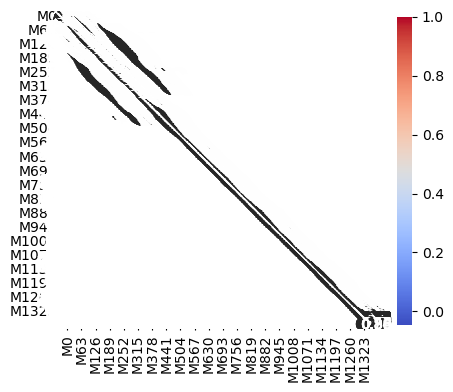

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Display a correlation matrix heatmap
corr_matrix = df.corr()
plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()


In [7]:
X = df.drop('Label', axis=1)  # Drop the target column to obtain features
y = df['Label']                # Target variable


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [9]:
from sklearn.decomposition import PCA

# Assume you have preprocessed your data into X (features) and y (labels/target)
pca = PCA(n_components=0.95)  # Keep 95% of the variance
X_pca = pca.fit_transform(X)


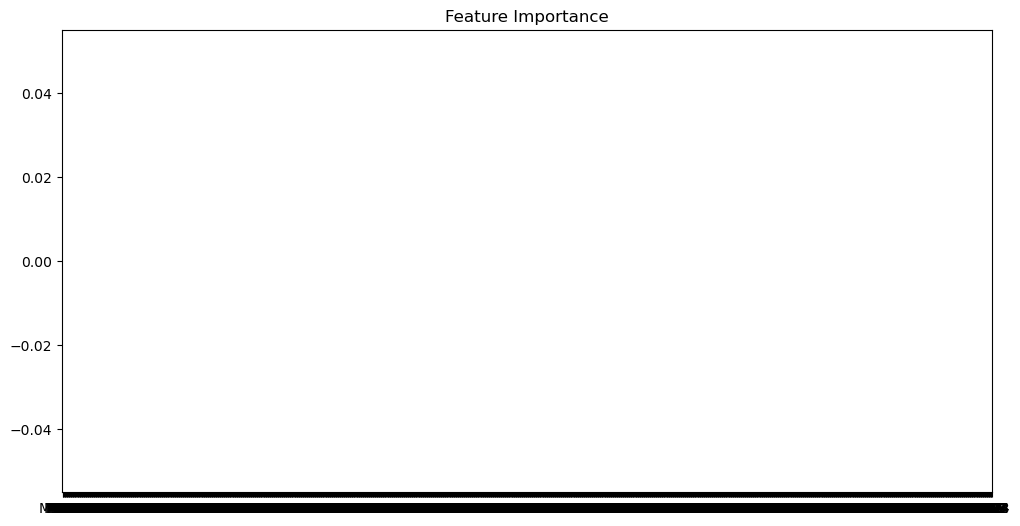

In [12]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

clf = RandomForestClassifier()
clf.fit(X, y)
importances = clf.feature_importances_

# Sort feature importances in descending order and visualize
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(12, 6))
sns.barplot(x=df.columns[indices], y=importances[indices])
plt.title("Feature Importance")
plt.show()
